In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
import os

In [3]:
conn = duckdb.connect("../results/results.duckdb")

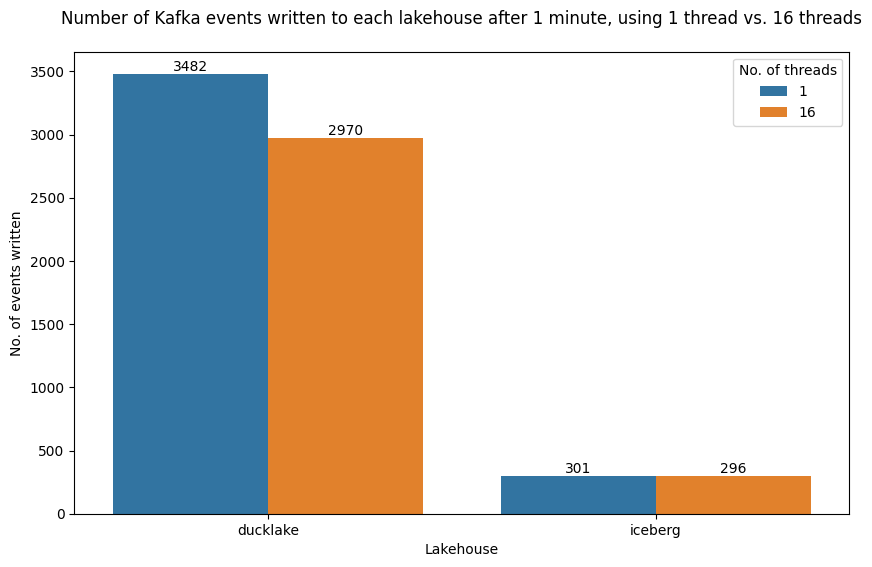

In [9]:
FILE_NAME = "imgs/initial-thread-comparison.eps"

events_consumed = conn.query("SELECT experiments.lakehouse, COUNT(events.*) AS events_consumed, experiments.n_threads " \
"FROM experiments " \
"JOIN events ON events.experiment_id = experiments.id " \
"WHERE experiments.id IN (2,3,6,7) " \
"GROUP BY experiments.id, experiments.lakehouse, experiments.n_threads;").fetchnumpy()

plt.figure(figsize=(10,6))
ax = plt.subplot()
ax.set_title("Number of Kafka events written to each lakehouse after 1 minute, using 1 thread vs. 16 threads", pad=20.0)
ax.set_xlabel("Lakehouse")
ax.set_ylabel("No. of events written")
sns.barplot(events_consumed, x="lakehouse", y="events_consumed", hue="n_threads", ax=ax, palette=sns.color_palette(n_colors=2))
ax.legend(title="No. of threads")

for container in ax.containers:
    ax.bar_label(container)

# ax.set_xticks(range(len(events_consumed["lakehouse"])), events_consumed["lakehouse"])
# ax.set_xticklabels(events_consumed["lakehouse"])
if not os.path.exists(FILE_NAME):
    plt.savefig(FILE_NAME)
plt.show()